### In this notebook the evolution of the chosen metrics over the pathway of chondrochloren and salvianolactone is computed.

First, all the necessairy libraries and packages are imported for the work with SMILES and also all the necesities for using the selected metics.

In [1]:

import rdkit
from rdkit import Chem
from rdkit.Chem import  Draw
from rdkit.Chem import rdChemReactions
from rdkit.Chem.SpacialScore import SPS
from rdkit.Chem import rdFingerprintGenerator
import os
import sys
from rdkit import RDConfig
from rdkit.Chem import Descriptors

sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
import sascorer

splitReactions takes as an input a set of reactions and for each separates the reactants and the products. In case of problems such as Invalid SMILES or no reactants an error message is returned and given reaction is skipped. After iterating through all of the reaction the reactants and products of all of them are returned separately.

In [2]:
def splitReactions(reactions):
    reactants = []
    products = []
    for rxn in reactions:
        parts =  rxn.split(">")
        if parts[0] == "":
            print("There are no reactants for ths reaction.\n")
            continue
        if parts[-1] == "":
            print("There are no products for ths reaction.\n")
            continue
        #reacts = react.split(".")
        mol = Chem.MolFromSmiles(parts[0])
        if mol is None: 
            print("Invalid SMILES.\n")
        reactants.append(mol)
        #prods = prod.split(".")
        molp = Chem.MolFromSmiles(parts[-1])
        if mol is None: 
            print("Invalid SMILES.\n")
        products.append(molp)
    return reactants, products
        

In the following cells all the metrics are computed. They all take as input molecules generated from smiles that are than used to calculate their score for given metric. 

For getnSAScore and getFPNorm the heavy atom count, computed in getHAC is also necessairy. 

For the getFPNorm the generator is set on radius 2 and fpSize 2048.

In [3]:
def getSAScore(data):
    scores = []
    for i in data:
        scores.append(sascorer.calculateScore(i))
    #print(len(scores))
    return scores

In [4]:
def getSPS(data):
    sps = []
    for i in data:
        x = SPS(i, normalize = False)
        sps.append(x)
    return sps

In [5]:
def getnSPS(data):
    nSPS = []
    for i in data:
        nSPS.append(SPS(i, normalize = True))
    return nSPS

In [40]:
def getHAC(data):
    hac = []
    for i in data:
        hac.append(i.GetNumAtoms())
    return hac

In [7]:
def getnSAScore(dataSA, dataHAC):
    nSA = []
    for i in range(0, len(dataSA)):
        nSA.append(dataSA[i]/dataHAC[i])
    return nSA

In [8]:
def getFpNorm(data, hac):
    generateFp = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
    normBit = []
    for i in range(0, len(data)):
        normBit.append(generateFp.GetFingerprint(data[i]).GetNumOnBits()/hac[i])
    return normBit


In [9]:
def getBertz(data):
    bertz = []
    for i in data:
        bertz.append(Descriptors.BertzCT(i))
    return bertz

In [20]:
def getMC1(data):
    mc1 = []
    for i in data:
        numDivalent = sum(1 for atom in i.GetAtoms()
                         if atom.GetDegree()==2)
        mc1.append(1-(numDivalent/(i.GetNumAtoms())))
    return mc1
        

getDeltas calculate the difference between the value of the score between reactants and products by simple substraction and returns the difference.

In [12]:
def getDeltas(reactants, products):
    deltas = []
    for i in range(0,len(reactants)):
        deltas.append(products[i] - reactants[i])
    return deltas

normalize takes as input the scores(usually coming from getDelta) and returns them normalized between 0 and 1.

In [43]:
def normalize(scores):
    minimum = min(scores)
    maximum = max(scores)
    normalized = []
    for i in scores:
        normalized.append((i-minimum)/(maximum-minimum))
    return normalized

makeGraph uses matplotlib to plot a graphic representation of all of the metrics evolution over the pathway.

In [35]:
import matplotlib.pyplot as plt

def makeGraph(sa, nsa, sps, nsps, hac, fp, bertz, mc1, name):
    x = list(range(1, len(sa)+1))
    plt.plot(x, sa, color ='#FF5768', label = "SA")
    plt.plot(x, sps, color = '#00A5E3', label = "SPS")
    plt.plot(x, nsps, color = '#8DD7BF', label = "nSPS")
    plt.plot(x, hac, color = '#FFBF65', label = "HAC")
    plt.plot(x, fp, color = '#74737A', label = "fps")
    plt.plot(x, nsa, color = '#FF96C5', label = "nSA")
    plt.plot(x, bertz, color = '#C05780', label = "Bertz")
    plt.plot(x, mc1, color = '#CFF800', label = "MC1")
    plt.xlabel("Reaction")
    plt.ylabel("Value")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(f"{name}.png")
    plt.show()

Following two cells take a text file containing reactions in form of SMILES, reads them and convert them into molecules. Then all of the metrics for all of the reactants and products are calculated, along the deltas which are then normalized and ploted.

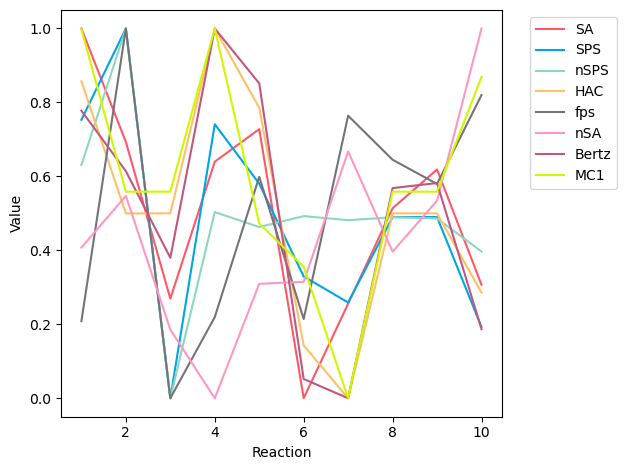

In [48]:
reactions = []
with open("Chondrochloren.txt") as f:
    for line in f:
        rxn = line.strip()
        if (rxn.count('>')==2):
            reactions.append(rxn)
        else: print("Invalid reaction.\n")
reactants, products = splitReactions(reactions)
rSAScore = []
rSAScore = getSAScore(reactants)
pSAScore = []
pSAScore = getSAScore(products)
rsps = []
rsps = getSPS(reactants)
psps = []
psps = getSPS(products)
rnsps = []
rnsps = getnSPS(reactants)
pnsps = []
pnsps = getnSPS(products)
rhac = []
rhac = getHAC(reactants)
phac = []
phac = getHAC(products)
rnSAScore = []
rnSAScore = getnSAScore(rSAScore, rhac)
pnSAScore = []
pnSAScore = getnSAScore(pSAScore, phac)
rfpNorm = []
rfpNorm = getFpNorm(reactants, rhac)
pfpNorm = []
pfpNorm = getFpNorm(products, phac)
rBertz = []
rBertz = getBertz(reactants)
pBertz = []
pBertz = getBertz(products)
rMc1 = []
rMc1 = getMC1(reactants)
pMc1 = []
pMc1 = getMC1(products)


SA = getDeltas(rSAScore, pSAScore)
nSA = getDeltas(rnSAScore, pnSAScore)
sps = getDeltas(rsps, psps)
nsps = getDeltas(rnsps, pnsps)
hac = getDeltas(rhac, phac)
fp = getDeltas(rfpNorm, pfpNorm)
bertz = getDeltas(rBertz, pBertz)
mc1 = getDeltas(rMc1, pMc1)

SAScoren = normalize(SA)
nSAScoren = normalize(nSA)
spsn = normalize(sps)
nspsn = normalize(nsps)
hacn  = normalize(hac)
fpn = normalize(fp)
bertzn = normalize(bertz)
mc1n = normalize(mc1)
makeGraph(SAScoren, nSAScoren, spsn, nspsn, hacn, fpn, bertzn, mc1n, "Chondrochloren")


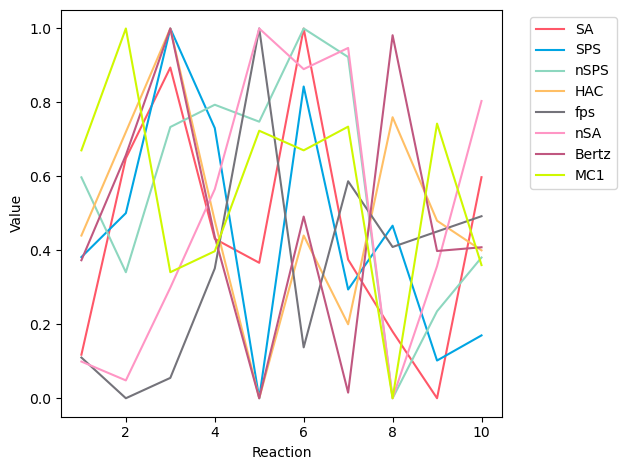

In [49]:
reactions = []
with open("Punctaporonin.txt") as f:
    for line in f:
        rxn = line.strip()
        if (rxn.count('>')==2):
            reactions.append(rxn)
        else: print("Invalid reaction.\n")
reactants, products = splitReactions(reactions)
rSAScore = []
rSAScore = getSAScore(reactants)
pSAScore = []
pSAScore = getSAScore(products)
rsps = []
rsps = getSPS(reactants)
psps = []
psps = getSPS(products)
rnsps = []
rnsps = getnSPS(reactants)
pnsps = []
pnsps = getnSPS(products)
rhac = []
rhac = getHAC(reactants)
phac = []
phac = getHAC(products)
rnSAScore = []
rnSAScore = getnSAScore(rSAScore, rhac)
pnSAScore = []
pnSAScore = getnSAScore(pSAScore, phac)
rfpNorm = []
rfpNorm = getFpNorm(reactants, rhac)
pfpNorm = []
pfpNorm = getFpNorm(products, phac)
rBertz = []
rBertz = getBertz(reactants)
pBertz = []
pBertz = getBertz(products)
rMc1 = []
rMc1 = getMC1(reactants)
pMc1 = []
pMc1 = getMC1(products)


SA = getDeltas(rSAScore, pSAScore)
nSA = getDeltas(rnSAScore, pnSAScore)
sps = getDeltas(rsps, psps)
nsps = getDeltas(rnsps, pnsps)
hac = getDeltas(rhac, phac)
fp = getDeltas(rfpNorm, pfpNorm)
bertz = getDeltas(rBertz, pBertz)
mc1 = getDeltas(rMc1, pMc1)

SAScoren2 = normalize(SA)
nSAScoren2 = normalize(nSA)
spsn2 = normalize(sps)
nspsn2 = normalize(nsps)
hacn2  = normalize(hac)
fpn2 = normalize(fp)
bertzn2 = normalize(bertz)
mc1n2 = normalize(mc1)
makeGraph(SAScoren2, nSAScoren2, spsn2, nspsn2, hacn2, fpn2, bertzn2, mc1n2, "Punctaporonin")

Simpler plot for two of the metrics with some similarity in each of the pathways.

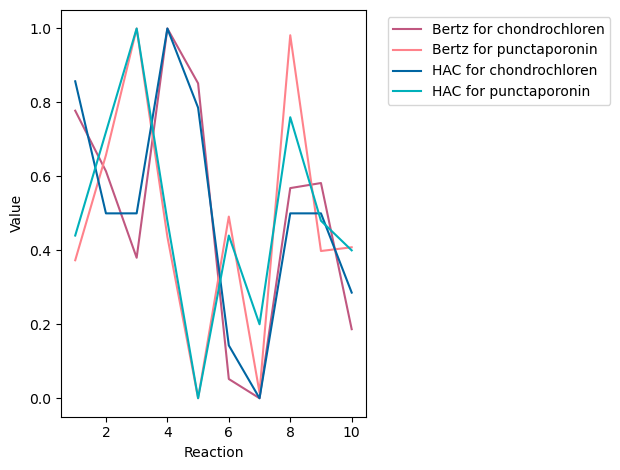

In [50]:
x = list(range(1, len(bertz)+1))
plt.plot(x, bertzn, color ='#C05780', label = "Bertz for chondrochloren")
plt.plot(x, bertzn2, color = '#FF828B', label = "Bertz for punctaporonin")
plt.plot(x, hacn, color = '#0065A2', label = "HAC for chondrochloren")
plt.plot(x, hacn2, color = '#00B0BA', label = "HAC for punctaporonin")
plt.xlabel("Reaction")
plt.ylabel("Value")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("bertzAndHAC.png")
plt.show()